In [48]:
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated, Literal
from dotenv import load_dotenv
from pydantic import BaseModel, Field
load_dotenv()

True

In [49]:
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated, Literal
from dotenv import load_dotenv
from pydantic import BaseModel, Field

load_dotenv()

class QuadState(TypedDict):
    a: int
    b: int
    c: int

    equation: str
    discriminant: float
    result: str


def showEquation(state: QuadState):
    equation= f"{state['a']}x2 + {state['b']}x + {state['c']}"
    # state['equation']= equation
    return {'equation': equation}

def calculateDiscriminant(state: QuadState):
    val= state['b']**2 - (4*state['a']*state['c'])
    return { 'discriminant' :val}

def real_roots(state: QuadState):
    root1= (-state['b'] + (state['discriminant']**0.5)/(2*state['a']))
    root2= (-state['b'] - (state['discriminant']**0.5)/(2*state['a']))
    return {'root1': {root1}, 'root2': {root2}}
    # return f" the roots are {root1} and {root2}"

def repeated_roots(state: QuadState):
    root= (-state['b']) /(2*state['a'])
    return {'root': {root}}
    # return f" the only root is {root}"

def no_real_roots(state: QuadState):
    result= f" No real root exist of this equation."
    return {'result': result}

def check_condition(state: QuadState) -> Literal["real_roots", "repeated_roots", "no_real_roots"]:

    if state['discriminant'] > 0:
        return "real_roots"
    elif state['discriminant'] == 0:
        return "repeated_roots"
    else:
        return "no_real_roots"


# now create a graph:
graph= StateGraph(QuadState)

# add nodes

graph.add_node('showEquation', showEquation)
graph.add_node('calculateDiscriminant', calculateDiscriminant)
graph.add_node('real_roots', real_roots)
graph.add_node('repeated_roots', repeated_roots)
graph.add_node('no_real_roots', no_real_roots)

# add the edges
graph.add_edge(START, 'showEquation')
graph.add_edge('showEquation', 'calculateDiscriminant' )
graph.add_edge('calculateDiscriminant', 'real_roots')
graph.add_edge('calculateDiscriminant', 'repeated_roots')
graph.add_edge('calculateDiscriminant', 'no_real_roots')

graph.add_edge('real_roots', END)
graph.add_edge('repeated_roots', END)
graph.add_edge('no_real_roots', END)

workflow= graph.compile()



state_temp={
    'a':3,
    'b':4,
    'c':5
}
abc=showEquation( state_temp)
print(f" abc: {abc}")

workflow.invoke(state_temp)


 abc: {'equation': '3x2 + 4x + 5'}


{'a': 3,
 'b': 4,
 'c': 5,
 'equation': '3x2 + 4x + 5',
 'discriminant': -44,
 'result': ' No real root exist of this equation.'}

In [50]:
class QuadState(TypedDict):
    a: int
    b: int
    c: int

    equation: str
    discriminant: float
    result: str



In [51]:
def showEquation(state: QuadState):
    equation= f"{state['a']}x2 + {state['b']}x + {state['c']}"
    # state['equation']= equation
    return {'equation': equation}

def calculateDiscriminant(state: QuadState):
    val= state['b']**2 - (4*state['a']*state['c'])
    return { 'discriminant' :val}

def real_roots(state: QuadState):
    root1= (-state['b'] + (state['discriminant']**0.5)/(2*state['a']))
    root2= (-state['b'] - (state['discriminant']**0.5)/(2*state['a']))
    return {'root1': {root1}, 'root2': {root2}}
    # return f" the roots are {root1} and {root2}"

def repeated_roots(state: QuadState):
    root= (-state['b']) /(2*state['a'])
    return {'root': {root}}
    # return f" the only root is {root}"

def no_real_roots(state: QuadState):
    result= f" No real root exist of this equation."
    return {'result': result}

def check_condition(state: QuadState) -> Literal["real_roots", "repeated_roots", "no_real_roots"]:

    if state['discriminant'] > 0:
        return "real_roots"
    elif state['discriminant'] == 0:
        return "repeated_roots"
    else:
        return "no_real_roots"



In [52]:
# now create a graph:
graph= StateGraph(QuadState)

# add nodes

graph.add_node('showEquation', showEquation)
graph.add_node('calculateDiscriminant', calculateDiscriminant)
graph.add_node('real_roots', real_roots)
graph.add_node('repeated_roots', repeated_roots)
graph.add_node('no_real_roots', no_real_roots)

# add the edges
graph.add_edge(START, 'showEquation')
graph.add_edge('showEquation', 'calculateDiscriminant' )
graph.add_edge('calculateDiscriminant', 'real_roots')
graph.add_edge('calculateDiscriminant', 'repeated_roots')
graph.add_edge('calculateDiscriminant', 'no_real_roots')

graph.add_edge('real_roots', END)
graph.add_edge('repeated_roots', END)
graph.add_edge('no_real_roots', END)

workflow= graph.compile()


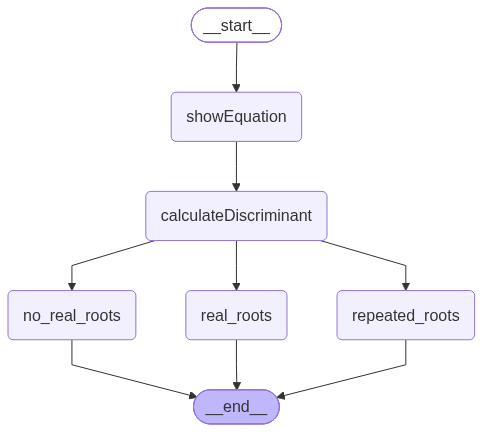

In [53]:
workflow

In [54]:
state_temp={
    'a':3,
    'b':4,
    'c':5
}
abc=showEquation( state_temp)
print(f" abc: {abc}")

workflow.invoke(state_temp)


 abc: {'equation': '3x2 + 4x + 5'}


{'a': 3,
 'b': 4,
 'c': 5,
 'equation': '3x2 + 4x + 5',
 'discriminant': -44,
 'result': ' No real root exist of this equation.'}